In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import nilearn
from nilearn import datasets
import nibabel as nib
from nilearn import plotting, image

# M/EEG plotting

### Topomap Based on PERCENTAGE of studies analyzing a coarse region

/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_3192/2047967534.py:93: RuntimeWarning: invalid value encountered in sqrt
  ear_left_x = -np.sqrt(0.2**2 - (ear_y**2)) - 1.1
/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_3192/2047967534.py:94: RuntimeWarning: invalid value encountered in sqrt
  ear_right_x = np.sqrt(0.2**2 - (ear_y**2)) + 1.1
/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_3192/2047967534.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('plasma')


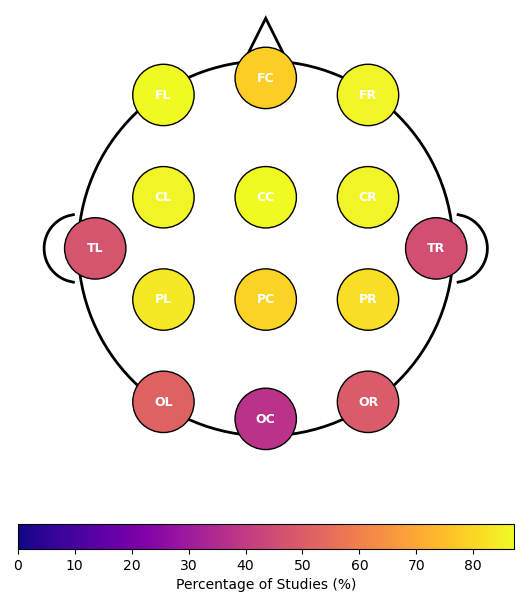

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

# Coordinates of coarse EEG/MEG regions (for topomap layout)
region_coords = {
    'FL': (-0.6, 0.9), 'FC': (0.0, 1.0), 'FR': (0.6, 0.9),
    'CL': (-0.6, 0.3), 'CC': (0.0, 0.3), 'CR': (0.6, 0.3),
    'PL': (-0.6, -0.3), 'PC': (0.0, -0.3), 'PR': (0.6, -0.3),
    'OL': (-0.6, -0.9), 'OC': (0.0, -1.0), 'OR': (0.6, -0.9),
    'TL': (-1.0, 0.0), 'TR': (1.0, 0.0)
}


def parse_covered_regions(entry):
    """
    Parses a 'Covered_Regions_COARSE' entry into region codes (e.g., FL, CC).
    Supports laterality tags: left, right, bilateral, midline.
    """
    regions = defaultdict(set)
    if not isinstance(entry, str):
        return set()

    entry = entry.upper().replace('-', '_').replace(',', '_')
    tokens = entry.split('_')

    i = 0
    while i < len(tokens):
        part = tokens[i]
        if not part:
            i += 1
            continue

        if all(c in 'FCOPT' for c in part):
            lobes = list(part)
            side = None
            if i + 1 < len(tokens):
                next_token = tokens[i + 1].lower()
                if 'bilateral' in next_token:
                    side = ['L', 'R']
                    i += 1
                elif 'left' in next_token:
                    side = ['L']
                    i += 1
                elif 'right' in next_token:
                    side = ['R']
                    i += 1
                elif 'midline' in next_token:
                    side = ['C']
                    i += 1
            if side is None:
                side = ['L', 'R', 'C']
            for lobe in lobes:
                for s in side:
                    regions[lobe].add(s)
        i += 1

    return {f"{lobe}{s}" for lobe, sides in regions.items() for s in sides}


def aggregate_region_counts(df):
    """
    Aggregates region counts into percentages based on the number of unique studies.
    Returns: dict of region -> percent of studies
    """
    counts = defaultdict(int)
    for val in df['Covered_Regions_COARSE']:
        for region in parse_covered_regions(val):
            counts[region] += 1

    n_studies = df['study'].nunique()
    for region in counts:
        counts[region] = (counts[region] / n_studies) * 100

    # Save to CSV for inspection
    pd.DataFrame(
        sorted(counts.items(), key=lambda x: x[1], reverse=True),
        columns=["Region", "Percentage"]
    ).to_csv("meeg_region_percentages.csv", index=False)

    return counts


def draw_head(ax):
    """Draws a stylized head outline, ears, and nose."""
    head = plt.Circle((0, 0), 1.1, color='black', fill=False, lw=2)
    ax.add_patch(head)

    ear_y = np.linspace(-0.4, 0.4, 100)
    ear_left_x = -np.sqrt(0.2**2 - (ear_y**2)) - 1.1
    ear_right_x = np.sqrt(0.2**2 - (ear_y**2)) + 1.1
    ax.plot(ear_left_x, ear_y, color='black', lw=2)
    ax.plot(ear_right_x, ear_y, color='black', lw=2)

    nose = plt.Polygon([[0, 1.35], [-0.1, 1.15], [0.1, 1.15]],
                       closed=True, fill=False, edgecolor='black', lw=2)
    ax.add_patch(nose)


def plot_region_topomap(region_counts, region_coords):
    """
    Plots a topographic map of EEG/MEG regions based on percentage of studies.
    Colorbar is horizontal and labeled for clarity.
    """
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_head(ax)

    values = list(region_counts.values())
    if not values:
        print("No regions found to plot.")
        return

    cmap = get_cmap('plasma')
    norm = Normalize(vmin=0, vmax=max(values))

    for region, percent in region_counts.items():
        coord = region_coords.get(region)
        if coord:
            circle = plt.Circle(coord, 0.18, color=cmap(norm(percent)), ec='black')
            ax.add_patch(circle)
            ax.text(*coord, region, ha='center', va='center', color='white',
                    weight='bold', fontsize=9)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.3, 1.4)
    ax.set_aspect('equal')
    ax.axis('off')

    # Horizontal colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.1)
    cbar.set_label("Percentage of Studies (%)")

    plt.savefig("meeg_topomap_percent.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# === Load and plot ===

df = pd.read_excel(
    "../scratch_plotting.xlsx",
    sheet_name="MEEG_ROIs"
)

region_counts = aggregate_region_counts(df)
plot_region_topomap(region_counts, region_coords)


# fMRI / fNIRS plotting

## Using Pedro's code to extract Harvard-Oxford atlas region MNI coordinates & plot

In [3]:
# first check the labels we'll use for region_value
# load & print
#atlas_ho = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
#labels = atlas_ho.labels
#for i, label in enumerate(labels):
    #print(f"{i}: {label}")

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 5623 voxels for region value 31


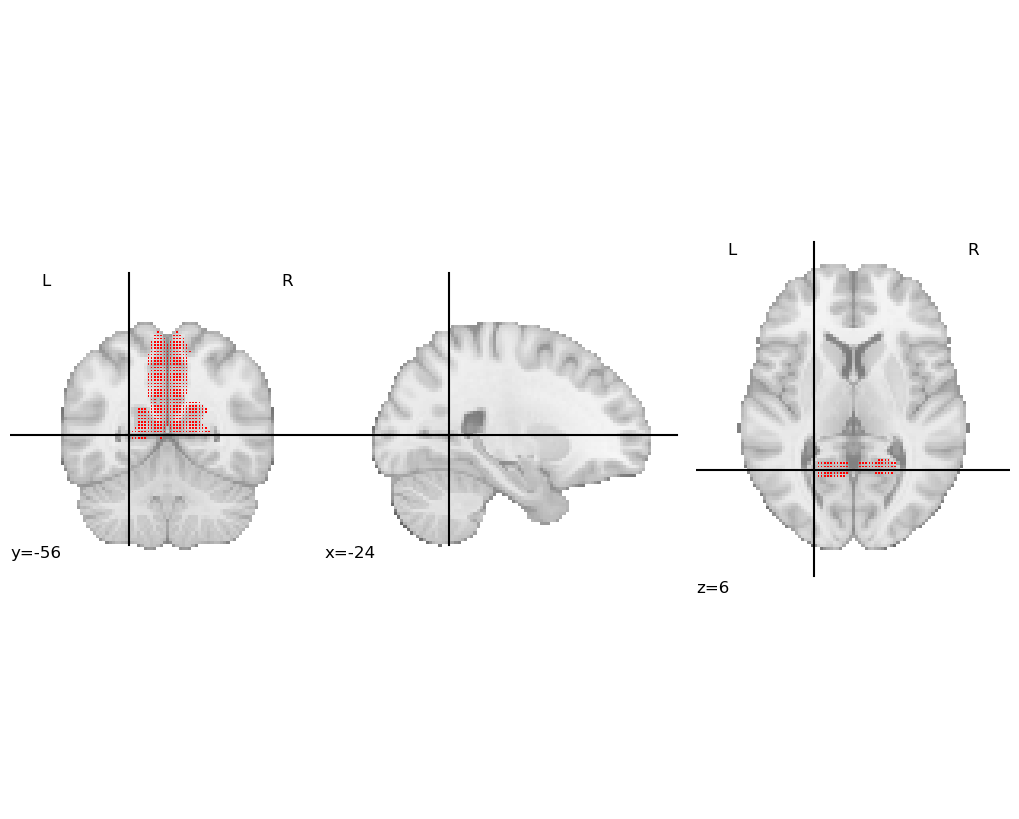

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1103 voxels for region value 5


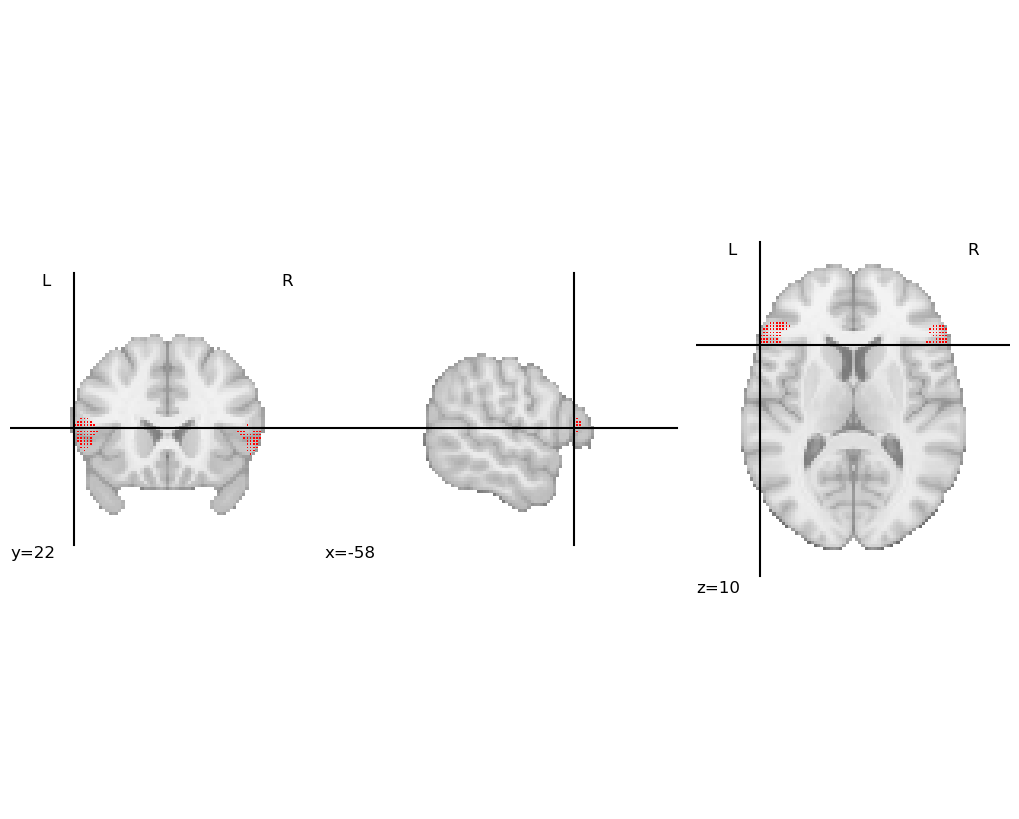

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1384 voxels for region value 6


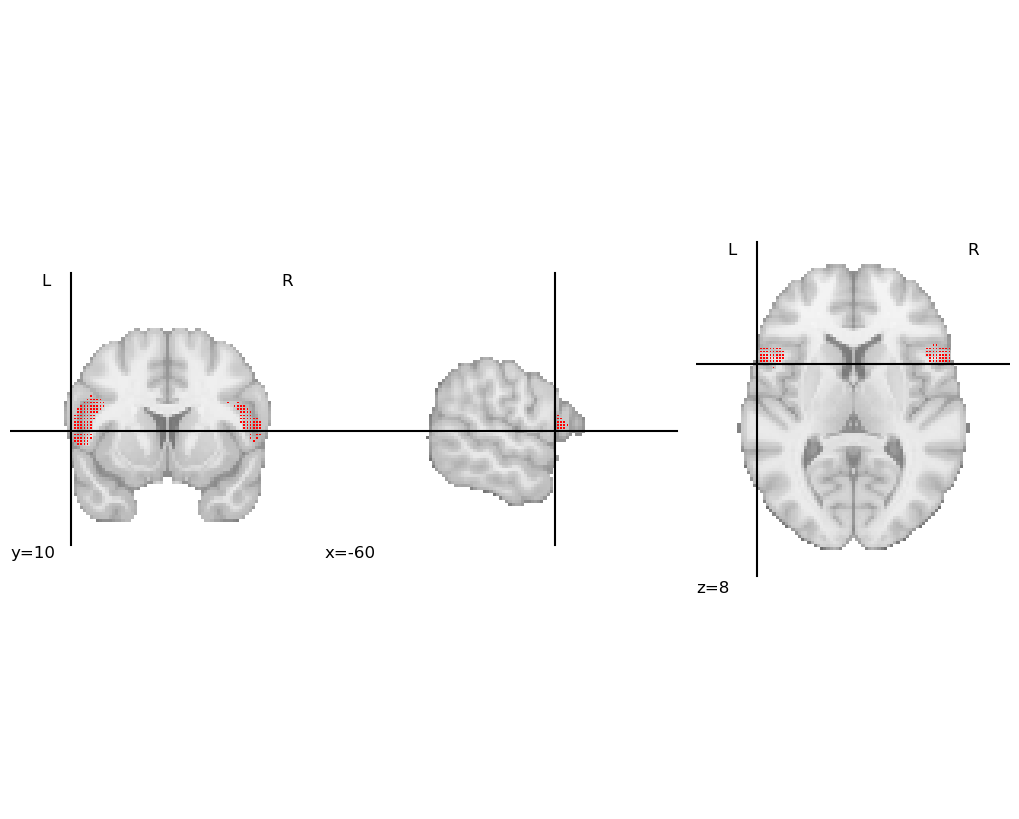

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 3148 voxels for region value 33


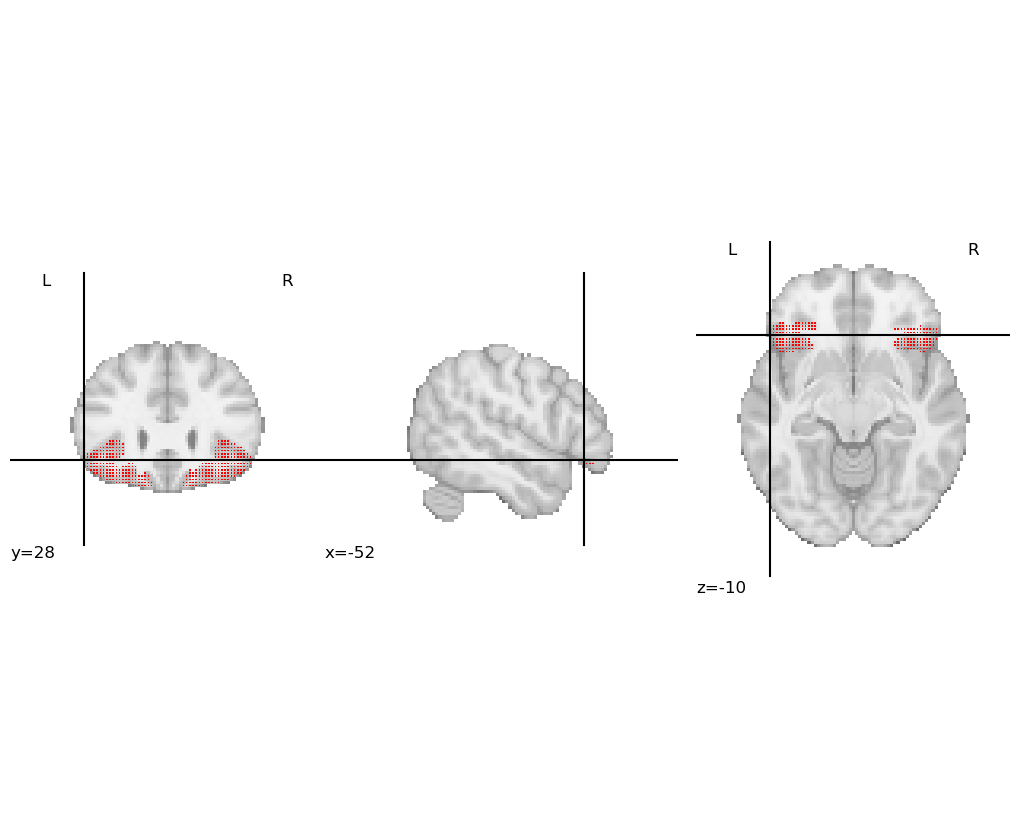

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 647 voxels for region value 14


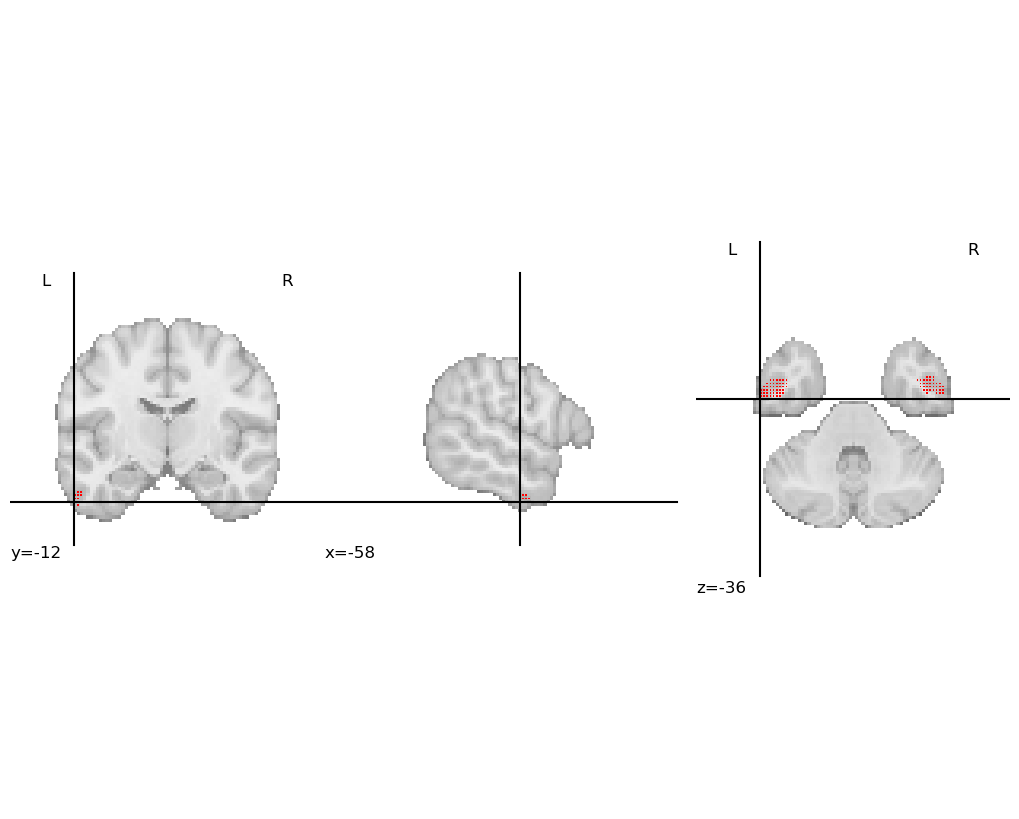

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 848 voxels for region value 11


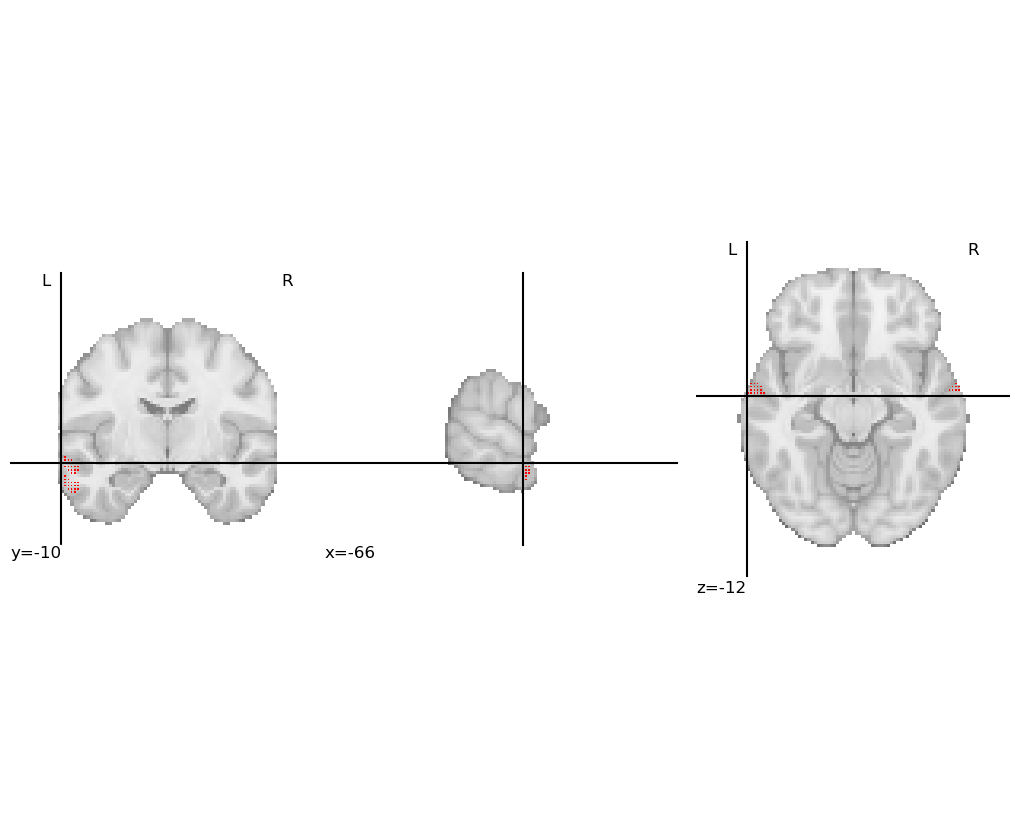

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 521 voxels for region value 9


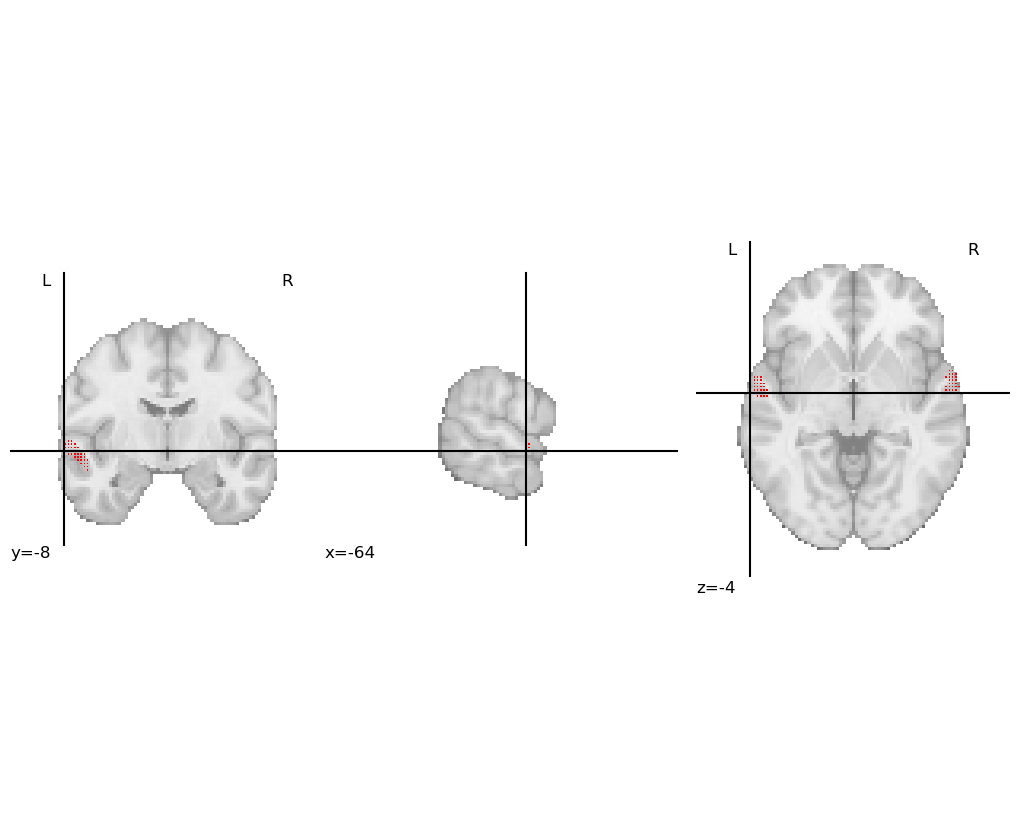

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1830 voxels for region value 10


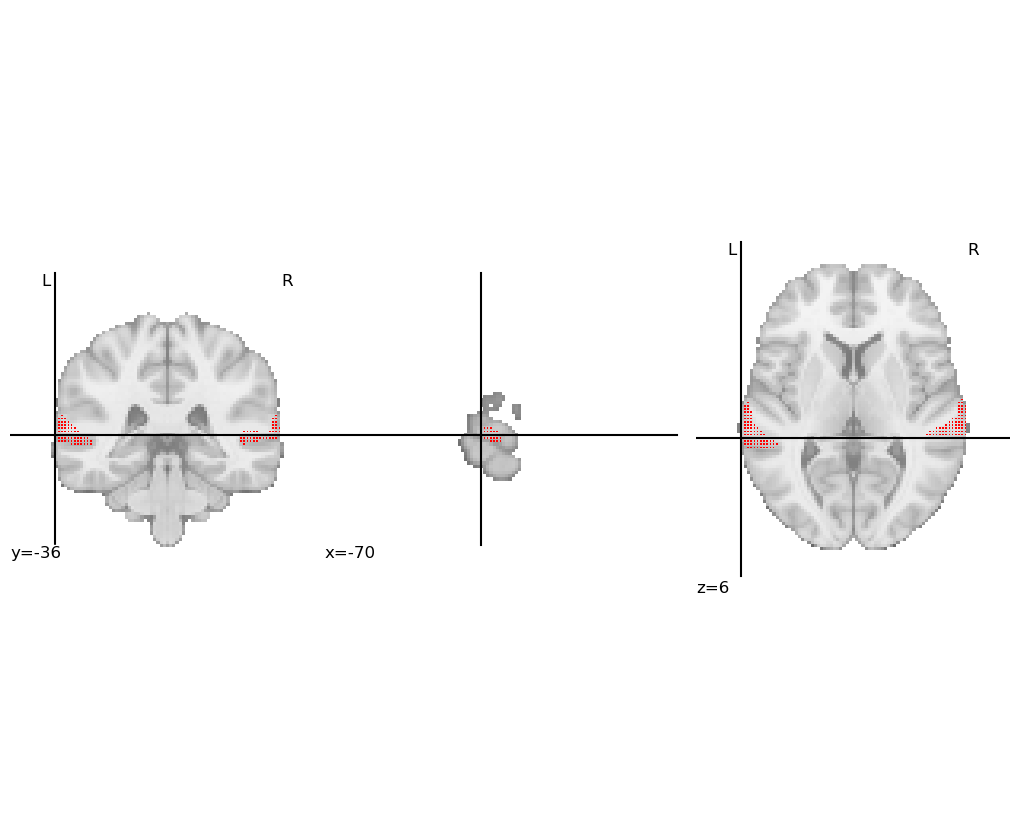

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 2525 voxels for region value 12


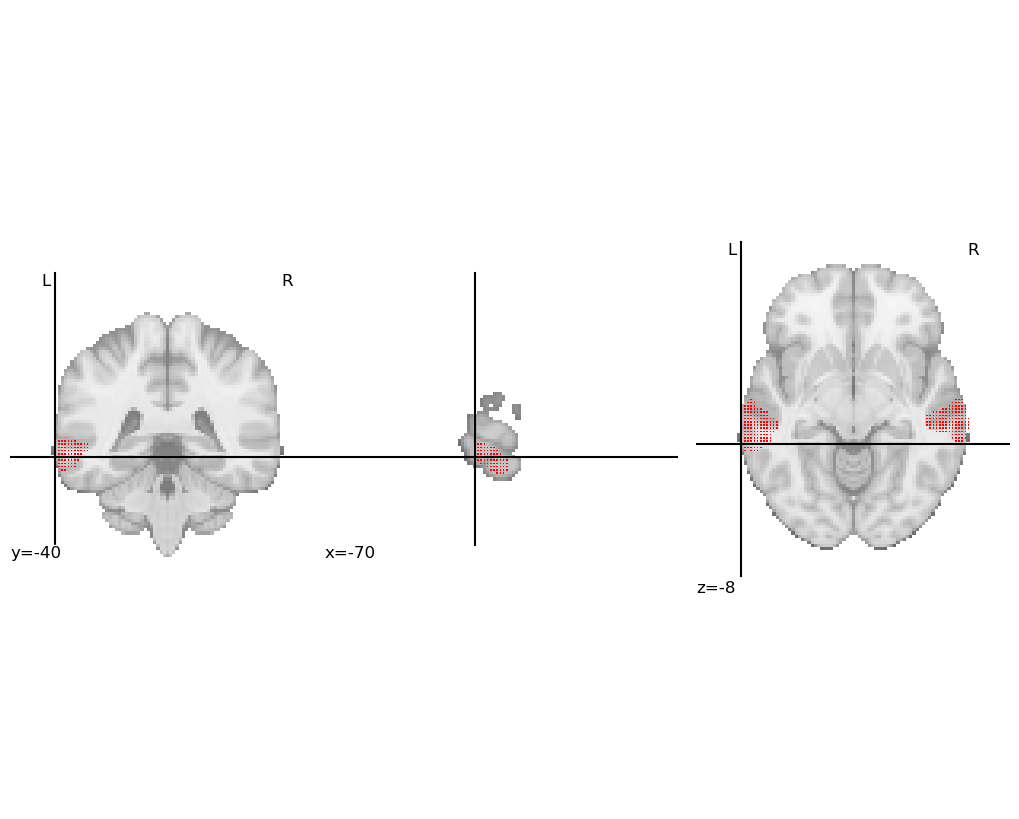

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 647 voxels for region value 14


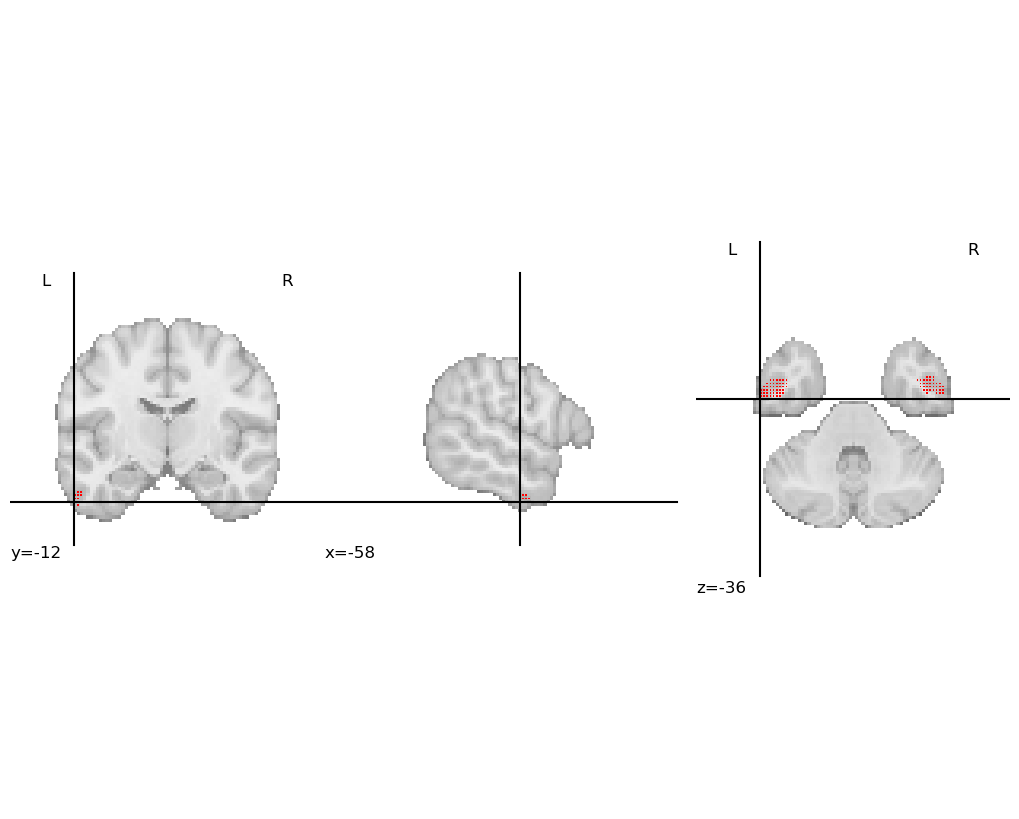

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1942 voxels for region value 15


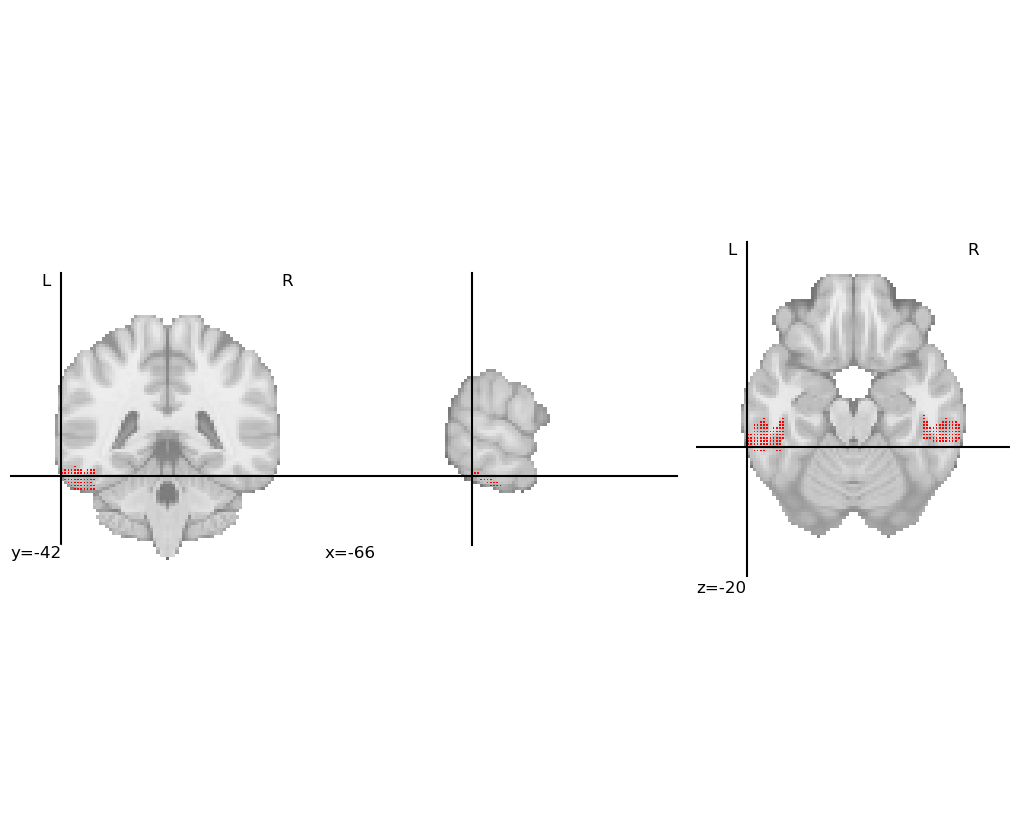

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 610 voxels for region value 37


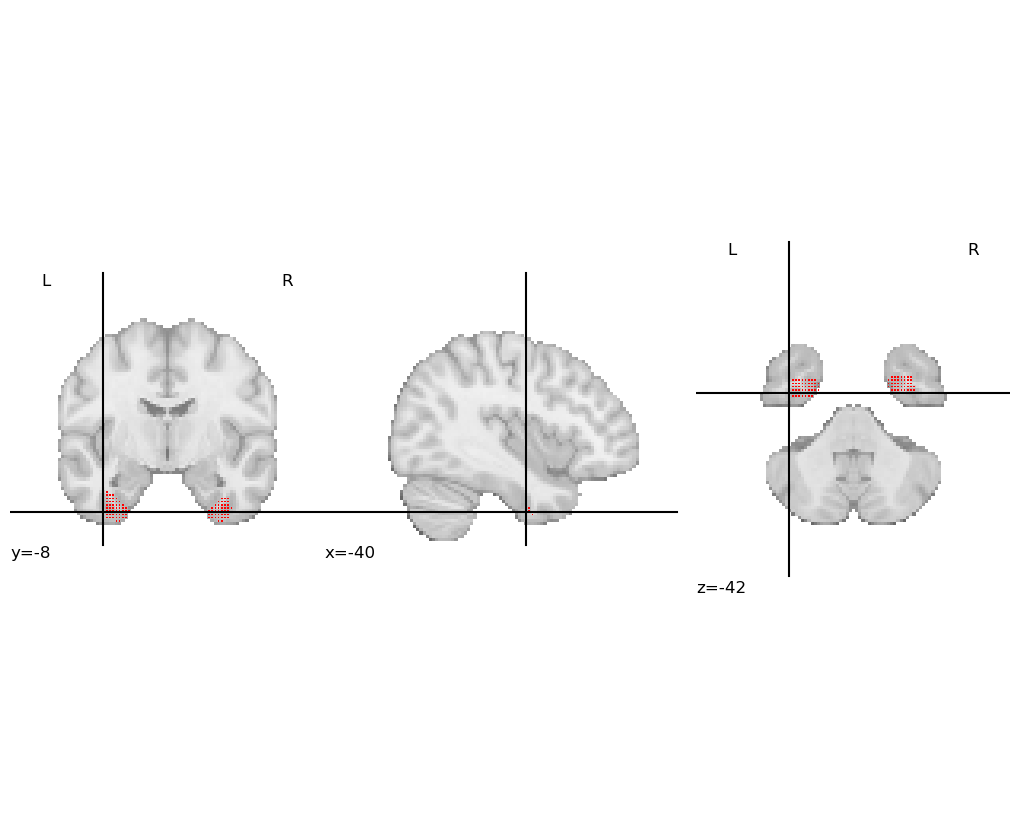

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1594 voxels for region value 38


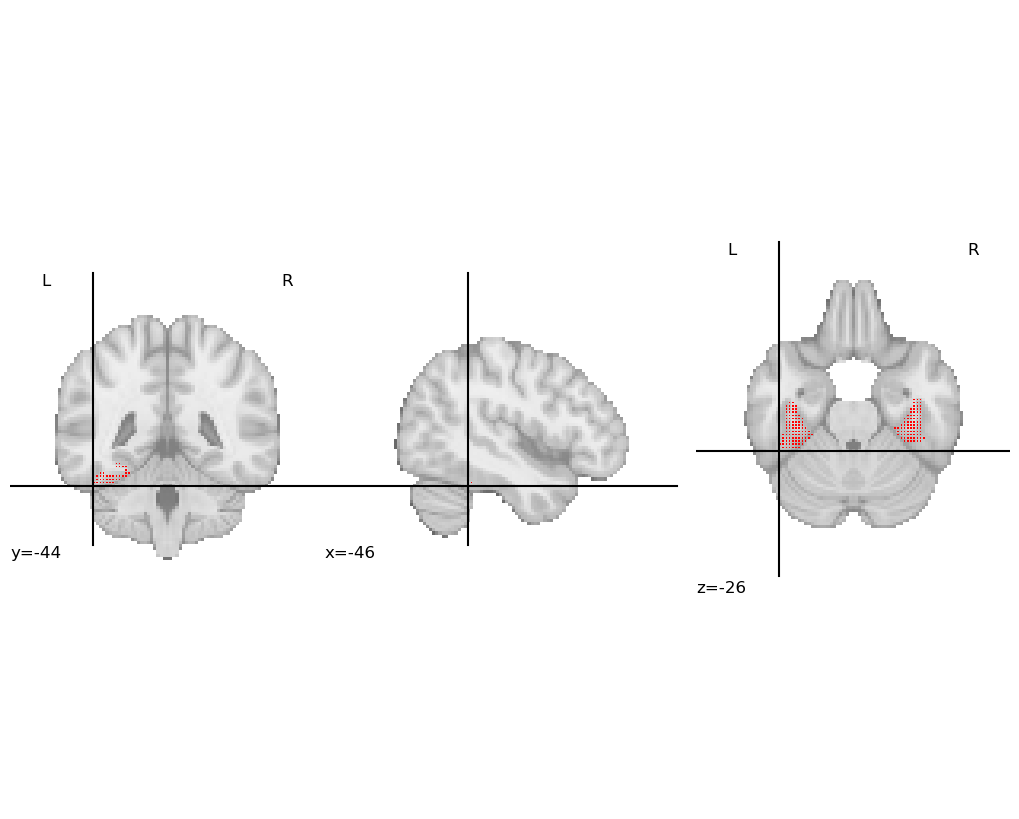

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1469 voxels for region value 39


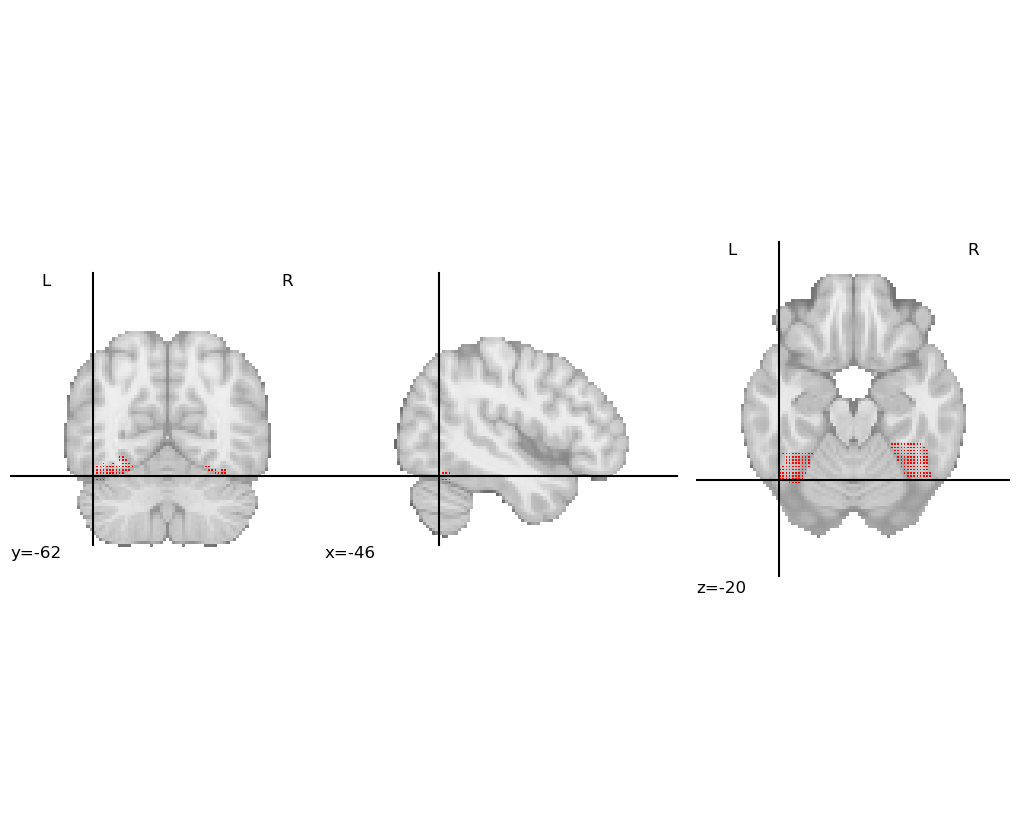

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1806 voxels for region value 40


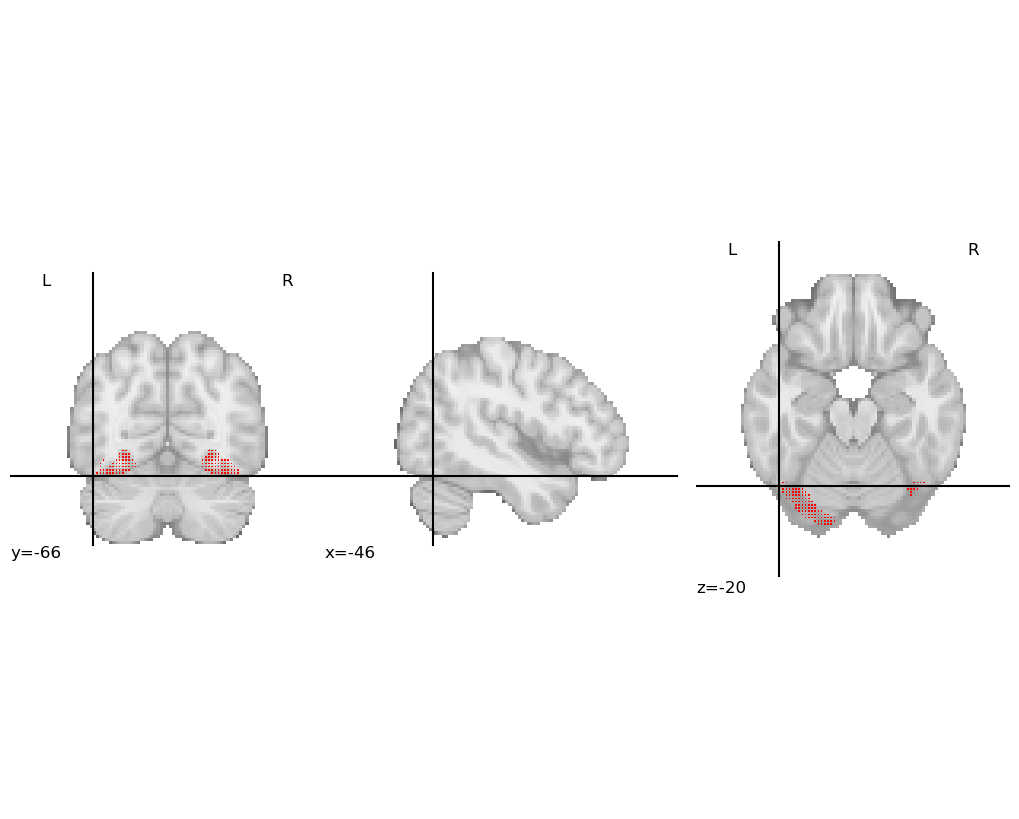

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 1742 voxels for region value 19


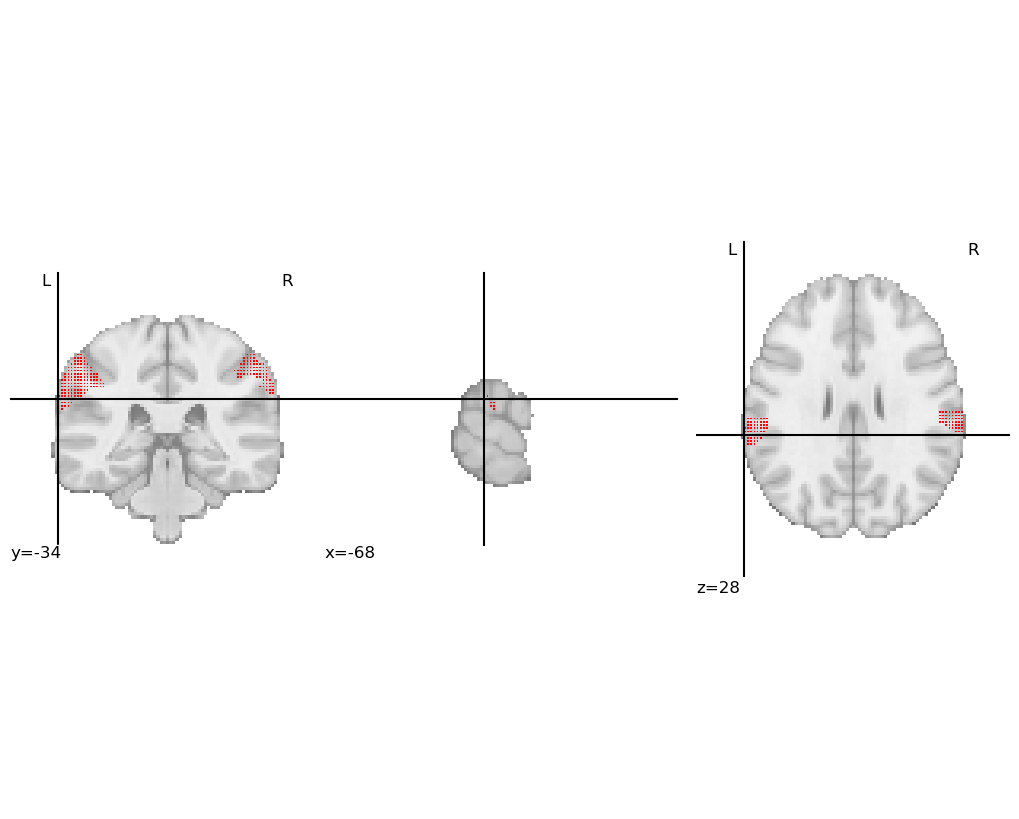

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 2259 voxels for region value 20


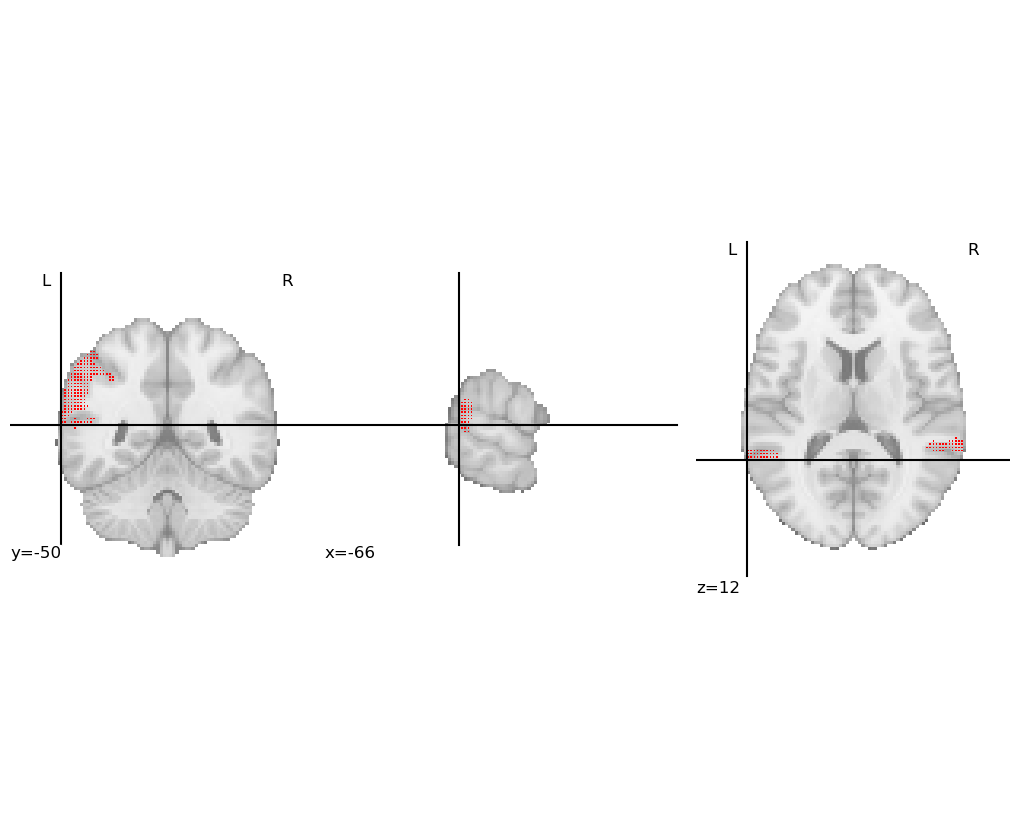

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 2409 voxels for region value 21


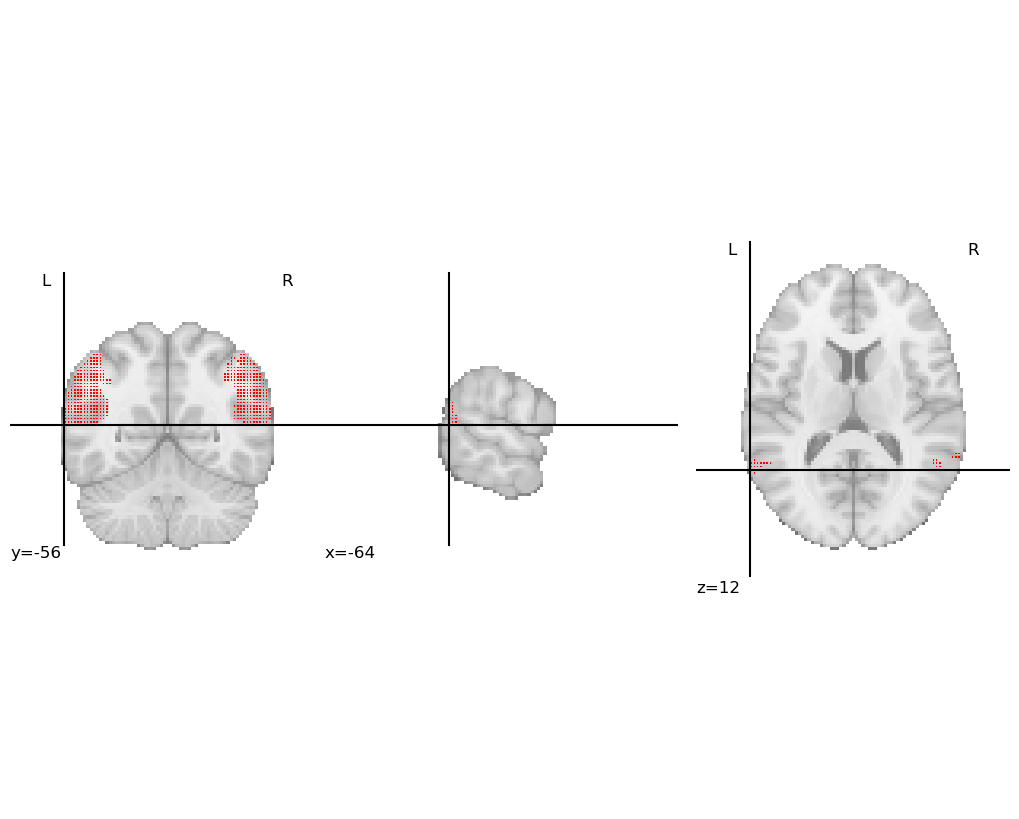

[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
Found 2908 voxels for region value 18


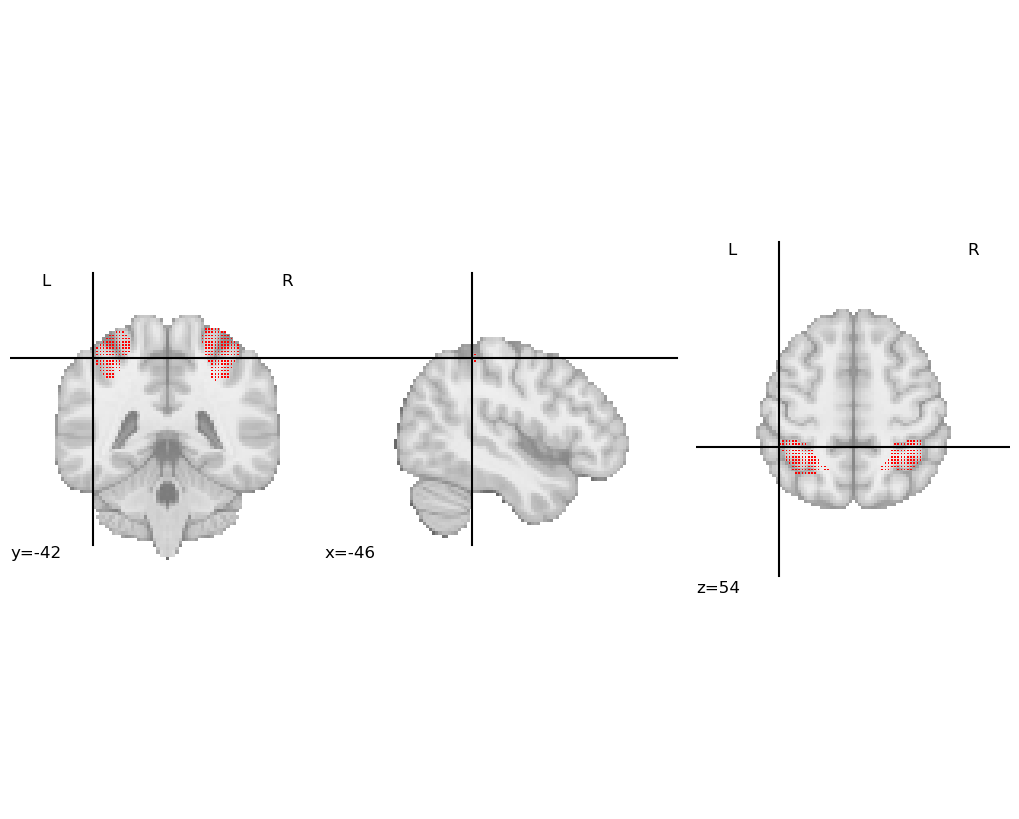

In [4]:
#%%
# https://github.com/neurocausal/neurocausal_meta/blob/main/atlas_labels_annotation.csv

#%%
def fetch_atlas(atlas_name):
    if atlas_name == 'mars_atlas':
        return None # find the volumetric atlas probably from file
    elif atlas_name == 'desikan_killiany':
        atlas_name = './ATLASES/aparcaseg.nii'
        return atlas_name # find the volumetric atlas probably from file
    if atlas_name == 'talariach_ba':
        return None # find the volumetric atlas probably from file
    if atlas_name == 'talariach_gyrus':
        return None # find the volumetric atlas probably from file
    if atlas_name == 'juelich':
        return nilearn.datasets.fetch_atlas_juelich('maxprob-thr25-1mm').maps
    elif atlas_name == 'harvard_oxford':
        return nilearn.datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm').maps
    elif atlas_name == 'destrieux':
        return nilearn.datasets.fetch_atlas_destrieux_2009().maps
    elif atlas_name == 'aal':
        return datasets.fetch_atlas_aal().maps
        #atlas_name = './AAL3v1.nii'
        return atlas_name
    elif atlas_name == 'ca_ml_mni':
        atlas_path = './ATLASES/MNIa_caez_ml_18_relabel.nii.gz'  # ML_CA_MNI
        return atlas_path
    elif atlas_name == 'tt_daemon':
        atlas_path = './ATLASES/TTatlas.nii'
        return atlas_path
    elif atlas_name == 'colin27':
        atlas_path = './ATLASES/MNI_caez_ml_18.nii'
        return atlas_path
    else:
        raise ValueError(f"Atlas {atlas_name} is not recognized or not supported in this function.")


#%%
def convert_to_mni(atlas_name, region_value):
    # Fetch the atlas
    atlas_obj = fetch_atlas(atlas_name)

    # Load the atlas if it's a file path, otherwise proceed with the Nifti image
    if isinstance(atlas_obj, str):
        atlas_img = nib.load(atlas_obj)
    else:
        atlas_img = atlas_obj

    atlas_data = atlas_img.get_fdata()

    # Identify the region
    region_voxels = np.argwhere(atlas_data == region_value)
    print(f"Found {region_voxels.shape[0]} voxels for region value {region_value}")

    # Convert the voxels to MNI space
    mni_coordinates = [nib.affines.apply_affine(atlas_img.affine, voxel) for voxel in region_voxels]

    return mni_coordinates


# %%
def create_mni_mask(mni_coordinates, template_shape, affine):
    """Create a binary mask in MNI space from the given coordinates."""
    mask = np.zeros(template_shape)
    for coord in mni_coordinates:
        voxel = nib.affines.apply_affine(np.linalg.inv(affine), coord).astype(int)
        mask[tuple(voxel)] = 1
    mask_img = nib.Nifti1Image(mask, affine=affine)
    return mask_img

def plot_anatomical_overlay(binary_mask_img):
    """Plot the binary mask on top of a standard MNI brain."""
    
    # Create a custom colormap that only contains the color red
    cmap = ListedColormap(['#000000', '#FF0000'])

    # Create a matplotlib figure with a specified size
    fig = plt.figure(figsize=(10, 8))
    
    # Plot
    plotting.plot_stat_map(binary_mask_img, display_mode='ortho', colorbar=False, 
                           threshold=0.5, cmap=cmap, figure=fig)
    plotting.show()


#%%
# Example usage:
#region_value = 81  # replace with the value for your region of interest
#mni_coords = convert_to_mni('colin27', region_value)
#binary_mask_img = create_mni_mask(mni_coords, template.shape, template.affine)
#plot_anatomical_overlay(binary_mask_img)
# %%
#atlas_list = ['colin27']
#region_value = 81  # replace with the value for your region of interest
#[plot_anatomical_overlay(create_mni_mask(convert_to_mni(atlas, region_value), template.shape, template.affine)) for atlas in atlas_list]

#%%
# loop thru multiple regions and print coords
region_values = [31, 5, 6, 33, 14, 11, 9, 10, 12, 14, 15, 37, 38, 39, 40, 19, 20, 21, 18]
template = nilearn.datasets.load_mni152_template()
atlas_name = 'harvard_oxford'

all_region_coords = {}
for region_value in region_values:
    mni_coords = convert_to_mni(atlas_name, region_value)
    all_region_coords[region_value] = mni_coords
    binary_mask_img = create_mni_mask(mni_coords, template.shape, template.affine)
    plot_anatomical_overlay(binary_mask_img)

## Mapping the MNI coordinates from our excel sheet to the Harvard-Oxford Atlas

### Based on PERCENTAGES and with a cerebellar map

Possible caudate coord: (-12, 9, 6) from study: Liu et al. (2023)
Included studies: 21
Excluded studies: 50
Reasons for exclusion:
reason
Not MNI space    45
Parse error       5
Name: count, dtype: int64
Saved list of excluded studies to 'excluded_studies.csv'
[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/licata/nilearn_data/fsl


/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_3192/1986752036.py:79: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  suit_rs    = image.resample_to_img(suit_img, ho_img, interpolation="nearest")
/var/folders/tw/kccyk0b139z3w564phcppjnm0000gp/T/ipykernel_3192/1986752036.py:79: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  suit_rs    = image.resample_to_img(suit_img, ho_img, interpolation="nearest")


Heat-map saved to combined_roi_frequency.nii.gz
Saved plot to: combined_roi_plot.png


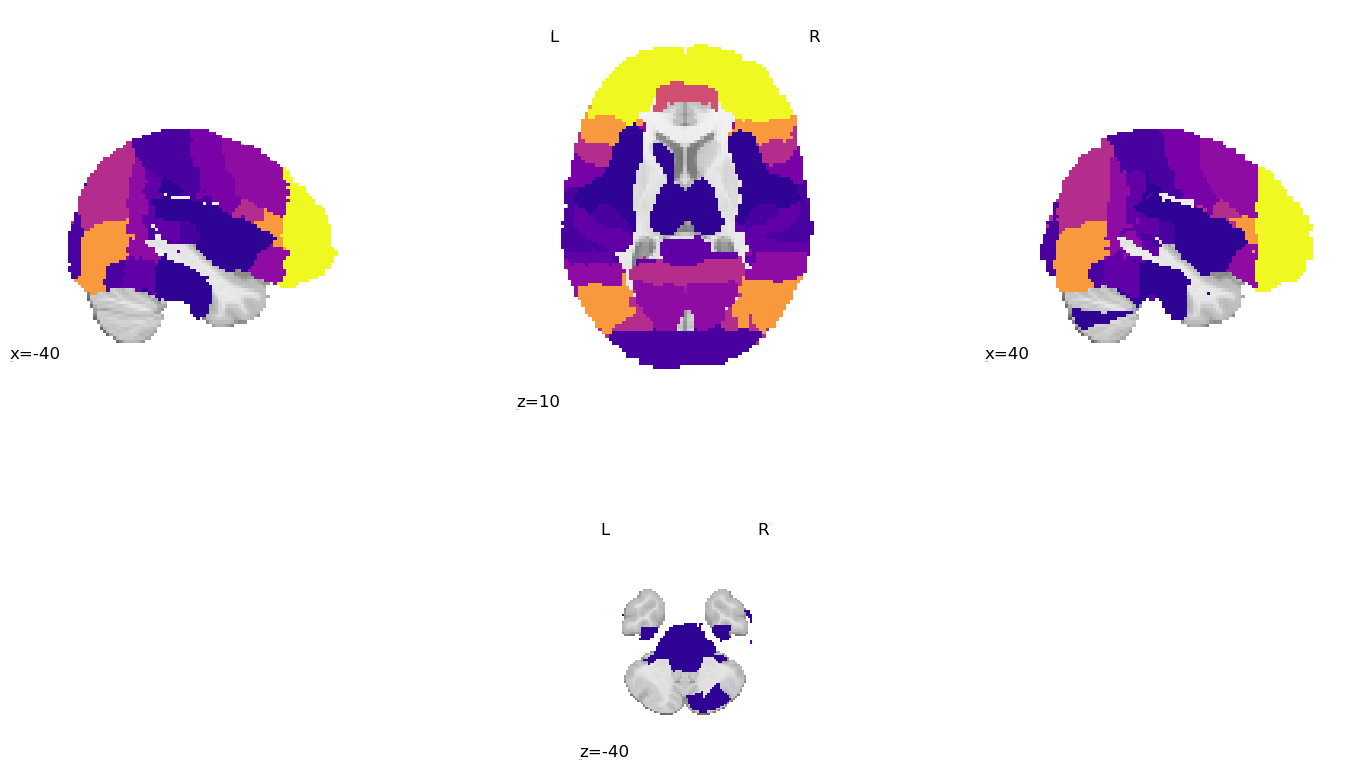

In [5]:
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn import datasets, plotting
from collections import Counter
import matplotlib.pyplot as plt

# Liu et al. (2023) caudate + Gurunandan et al. (2023) coords don't get correctly mapped, we need to override them
coord_overrides = {
    (-12, 9, 6): "Caudate",                  # Liu et al. (2023)
    (-62, -48, -20): "Cingulate",            # caudal ACC (L)
    (-64, 20, -12): "Cingulate",             # caudal ACC (R)
    (-24, -63, -35): "Left_VI",              # manually verified SUIT
    (24, -63, -35): "Right_VI",              # manually verified SUIT
    (20, -78, -35): "Right_CrusII",         # manually verified SUIT
}

def load_coordinates_and_count_studies(file_path, sheet_name="rois_mapping"):
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    included_rows = []
    excluded_rows = []

    for _, row in df.iterrows():
        study_label = row.get("study", "Unknown study")
        coords_str = str(row.get("coordinates", "")).strip()
        space = row.get("space", "")

        if space != "MNI":
            excluded_rows.append({"study": study_label, "reason": "Not MNI space"})
            continue
        if "NOCOORDINATES" in coords_str or "TABLE" in coords_str or coords_str == "":
            excluded_rows.append({"study": study_label, "reason": "Invalid coordinates"})
            continue

        coords_str_clean = coords_str.strip('()').replace(' ', '').replace(')', '').replace('(', '')
        try:
            coord_list = list(map(int, coords_str_clean.split(',')))
            if len(coord_list) % 3 != 0:
                excluded_rows.append({"study": study_label, "reason": "Malformed coordinate triplet"})
                continue
            for i in range(0, len(coord_list), 3):
                included_rows.append((study_label, tuple(coord_list[i:i+3])))
        except Exception:
            excluded_rows.append({"study": study_label, "reason": "Parse error"})

    used_study_ids = {study for study, _ in included_rows}
    excluded_df = pd.DataFrame(excluded_rows).sort_values("study")

    for study, coord in included_rows:
        if -15 <= coord[0] <= -9 and 8 <= coord[1] <= 12 and 6 <= coord[2] <= 10:
            print("Possible caudate coord:", coord, "from study:", study)
        
    print(f"Included studies: {len(used_study_ids)}")
    print(f"Excluded studies: {excluded_df['study'].nunique()}")
    print("Reasons for exclusion:")
    print(excluded_df.value_counts("reason"))

    if not excluded_df.empty:
        excluded_df.to_csv("excluded_studies.csv", index=False)
        print("Saved list of excluded studies to 'excluded_studies.csv'")

    return included_rows, len(used_study_ids), excluded_df

import numpy as np
import pandas as pd
import nibabel as nib
from collections import Counter
from nilearn import datasets, image


def _load_suit_atlas(label_img_path: str, label_table_path: str):
    """
    Resample SUIT dseg atlas (1 mm) to Harvard-Oxford 2 mm grid
    and return (img_resampled, label_list).
    """
    suit_img   = nib.load(label_img_path)
    ho_img     = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr0-2mm").maps
    suit_rs    = image.resample_to_img(suit_img, ho_img, interpolation="nearest")

    lut        = pd.read_csv(label_table_path, sep="\t")
    lbl_dict   = {int(r["index"]): r["name"] for _, r in lut.iterrows()}
    used_max   = int(suit_rs.get_fdata().max())
    labels     = ["Background"] * (used_max + 1)
    for k, v in lbl_dict.items():
        if k <= used_max:
            labels[k] = v
    return suit_rs, labels


def generate_combined_cortical_subcortical_map(
    study_coords,
    n_studies: int,
    save_path: str | None = None,
    coord_overrides: dict[tuple[int, int, int], str] | None = None,
    suit_img_path: str | None = None,
    suit_tsv_path: str | None = None,
):
    """
    Build a %-of-studies heat-map using Harvard-Oxford (cortex+subcortex)
    plus SUIT cerebellum, with explicit coordinate overrides.

    Returns
    -------
    freq_img      : nib.Nifti1Image
    region_perc   : Counter {ROI index -> percentage}
    atlas_labels  : list of ROI names (HO + SUIT)
    """

    # ── Load HO atlases ────────────────────────────────────────────────────
    cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr0-2mm")
    sub  = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr0-2mm")
    cort_data, aff = cort.maps.get_fdata(), cort.maps.affine
    sub_data       = sub.maps.get_fdata()

    # ── Load SUIT if paths given ──────────────────────────────────────────
    use_suit = bool(suit_img_path and suit_tsv_path)
    if use_suit:
        suit_img_rs, suit_labels = _load_suit_atlas(suit_img_path, suit_tsv_path)
        suit_data    = suit_img_rs.get_fdata().astype(int)
        suit_affine  = suit_img_rs.affine
    else:
        suit_data, suit_labels, suit_affine = None, [], aff

    atlas_labels = list(cort.labels) + list(sub.labels) + suit_labels
    merged_data  = np.zeros_like(cort_data, dtype=np.float32)
    region_hits, coord_to_lbl = [], []
    overrides = coord_overrides or {}

    # helper: ensure an ROI index exists, extending atlas_labels if needed
    def _index_for_suit_label(label_sub: str) -> int | None:
        """Return global ROI index for a SUIT label substring; extend list if new."""
        try_idx = next(
            (i for i, l in enumerate(atlas_labels) if label_sub in l.lower()),
            None,
        )
        if try_idx is not None:
            return try_idx
        # substring not found → try exact match in suit_labels
        for i, lbl in enumerate(suit_labels):
            if label_sub in lbl.lower():
                global_idx = i + len(cort.labels) + len(sub.labels)
                # extend atlas_labels list up to that index if missing
                while len(atlas_labels) <= global_idx:
                    atlas_labels.append("")         # pad
                atlas_labels[global_idx] = f"SUIT: {lbl}"
                return global_idx
        return None

    # ── Iterate through all coordinates ──────────────────────────────────
    for study, coord in study_coords:

        # 1️⃣ Manual override?
        if coord in overrides:
            target = overrides[coord].lower()
            idx = _index_for_suit_label(target)
            if idx is not None:
                region_hits.append(idx)
                coord_to_lbl.append(
                    (study, coord, f"{atlas_labels[idx]} (forced)")
                )
                # forcibly paint voxels for this ROI
                if use_suit and idx >= len(cort.labels) + len(sub.labels):
                    suit_idx = idx - len(cort.labels) - len(sub.labels)
                    pct_val  = (1 / n_studies) * 100
                    merged_data[suit_data == suit_idx] = pct_val
                continue

        # 2️⃣ Harvard-Oxford lookup
        voxel = nib.affines.apply_affine(np.linalg.inv(aff), coord).astype(int)
        label = "No ROI match"
        try:
            v_cort = int(cort_data[tuple(voxel)])
            if 0 < v_cort < len(cort.labels):
                idx, label = v_cort, cort.labels[v_cort]
                region_hits.append(idx)
            else:
                v_sub = int(sub_data[tuple(voxel)])
                if (
                    0 < v_sub < len(sub.labels)
                    and not any(k in sub.labels[v_sub].lower()
                                for k in ("white matter", "cerebral"))
                ):
                    idx  = v_sub + len(cort.labels)
                    label = sub.labels[v_sub]
                    region_hits.append(idx)
        except Exception:
            label = "Out of bounds"

        # 3️⃣ SUIT fallback
        if label == "No ROI match" and use_suit:
            vox_suit = nib.affines.apply_affine(
                np.linalg.inv(suit_affine), coord
            ).astype(int)
            if np.all((0 <= vox_suit) & (vox_suit < suit_data.shape)):
                v_suit = int(suit_data[tuple(vox_suit)])
                if 0 < v_suit < len(suit_labels):
                    idx  = v_suit + len(cort.labels) + len(sub.labels)
                    label = f"SUIT: {suit_labels[v_suit]}"
                    region_hits.append(idx)
        coord_to_lbl.append((study, coord, label))

    # ── Convert hit counts → percentages ──────────────────────────────────
    region_perc = Counter(region_hits)
    for k in list(region_perc):
        region_perc[k] = (region_perc[k] / n_studies) * 100

    # ── Paint voxels for every ROI with ≥ one hit ─────────────────────────
    for idx, pct in region_perc.items():
        if idx < len(cort.labels):
            merged_data[cort_data == idx] = pct
        elif idx < len(cort.labels) + len(sub.labels):
            merged_data[sub_data == (idx - len(cort.labels))] = pct
        else:
            suit_idx = idx - len(cort.labels) - len(sub.labels)
            if use_suit:
                merged_data[suit_data == suit_idx] = pct

    final_aff = suit_affine if use_suit else aff
    freq_img  = nib.Nifti1Image(merged_data, final_aff)

    if save_path:
        nib.save(freq_img, save_path)
        print(f"Heat-map saved to {save_path}")

    pd.DataFrame(coord_to_lbl,
                 columns=["Study", "MNI Coordinate", "ROI Label"]
                 ).to_csv("mni_to_combined_roi_mapping.csv", index=False)

    return freq_img, region_perc, atlas_labels


def plot_roi_frequency_map(freq_img, region_counts, n_studies, save_path=None):
    """
    Plots 3-view brain activation map + cerebellar slice with horizontal colorbar.
    """
    import matplotlib.pyplot as plt
    from nilearn import plotting
    import matplotlib.colorbar as cb
    import numpy as np

    vmax = max(region_counts.values()) if region_counts else 1
    threshold = 0.0

    # Create figure
    fig = plt.figure(figsize=(15, 10))  # Taller for extra subplot
    fig.patch.set_facecolor('white')

    # Axes positions
    ax1 = fig.add_axes([0.05, 0.55, 0.25, 0.4])    # Left
    ax2 = fig.add_axes([0.375, 0.55, 0.25, 0.4])   # Axial
    ax3 = fig.add_axes([0.7, 0.55, 0.25, 0.4])     # Right
    ax4 = fig.add_axes([0.375, 0.20, 0.25, 0.25])  # Cerebellum (z = -40)
    #cax = fig.add_axes([0.35, 0.08, 0.3, 0.03])    # Horizontal colorbar

    # Left hemisphere (x = -40)
    plotting.plot_stat_map(freq_img, display_mode='x', cut_coords=[-40], threshold=threshold,
                           vmax=vmax, cmap='plasma', colorbar=False, figure=fig, axes=ax1,
                           black_bg=False).annotate(size=0)

    # Axial slice (z = 10)
    plotting.plot_stat_map(freq_img, display_mode='z', cut_coords=[10], threshold=threshold,
                           vmax=vmax, cmap='plasma', colorbar=False, figure=fig, axes=ax2,
                           black_bg=False).annotate(size=0)

    # Right hemisphere (x = 40)
    plotting.plot_stat_map(freq_img, display_mode='x', cut_coords=[40], threshold=threshold,
                           vmax=vmax, cmap='plasma', colorbar=False, figure=fig, axes=ax3,
                           black_bg=False).annotate(size=0)

    # Cerebellum (z = -40)
    plotting.plot_stat_map(freq_img, display_mode='z', cut_coords=[-40], threshold=threshold,
                           vmax=vmax, cmap='plasma', colorbar=False, figure=fig, axes=ax4,
                           black_bg=False).annotate(size=0)
    #ax4.set_title("Cerebellum (z = -40)", fontsize=11)

    # Colorbar
    #norm = plt.Normalize(vmin=0, vmax=vmax)
    #cb1 = cb.ColorbarBase(cax, cmap='plasma', norm=norm, orientation='horizontal')
    #cb1.set_label("Percentage of Studies (%)", fontsize=12)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Saved plot to: {save_path}")

    plt.show()



# Paths to your SUIT atlas files
SUIT_IMG = "./ATLASES/atl-Anatom_space-MNI_dseg.nii"
SUIT_TSV = "./ATLASES/atl-Anatom.tsv"

mni_coords, n_studies, excluded_df = load_coordinates_and_count_studies(
    "../scratch_plotting.xlsx", sheet_name="fMRI-fNIRS_ROIs"
)

roi_img, roi_counts, roi_labels = generate_combined_cortical_subcortical_map(
    study_coords=mni_coords,
    n_studies=n_studies,
    save_path="combined_roi_frequency.nii.gz",
    coord_overrides=coord_overrides,
    suit_img_path=SUIT_IMG,
    suit_tsv_path=SUIT_TSV
)

plot_roi_frequency_map(roi_img, roi_counts, n_studies, save_path="combined_roi_plot.png")

# Merge the two images and create the final graph for the paper

In [6]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager as fm

def combine_figures_vertically_balanced(image_a_path, image_b_path,
                                        output_path="combined_balanced.png",
                                        label_a="a)", label_b="b)",
                                        target_height=1000, pad=30):
    """
    Stacks two images vertically with the same height and centered width.
    Adds large panel labels to the top-left of each section on the canvas.
    """
    img_a = Image.open(image_a_path)
    img_b = Image.open(image_b_path)

    def resize_to_height(img, height):
        ratio = height / img.height
        new_width = int(img.width * ratio)
        return img.resize((new_width, height), Image.LANCZOS)

    img_a_resized = resize_to_height(img_a, target_height)
    img_b_resized = resize_to_height(img_b, target_height)

    canvas_width = max(img_a_resized.width, img_b_resized.width)
    total_height = img_a_resized.height + img_b_resized.height + 3 * pad

    # Create a white canvas
    combined = Image.new("RGB", (canvas_width, total_height), "white")

    # Paste top image
    offset_a_x = (canvas_width - img_a_resized.width) // 2
    combined.paste(img_a_resized, (offset_a_x, pad))

    # Paste bottom image
    offset_b_x = (canvas_width - img_b_resized.width) // 2
    offset_b_y = img_a_resized.height + 2 * pad
    combined.paste(img_b_resized, (offset_b_x, offset_b_y))

    # Add labels using a large, scalable font
    draw = ImageDraw.Draw(combined)
    try:
        font_path = fm.findfont("DejaVu Sans")
        font = ImageFont.truetype(font_path, 40)
    except Exception as e:
        print("Font fallback due to:", e)
        font = ImageFont.load_default()

    draw.text((30, 30), label_a, fill="black", font=font)
    draw.text((30, offset_b_y + 30), label_b, fill="black", font=font)

    combined.save(output_path)
    print(f"Saved vertically stacked figure to: {output_path}")

In [7]:
combine_figures_vertically_balanced("meeg_topomap_percent.png", "combined_roi_plot.png", output_path="panel_figure_combined.png")

Saved vertically stacked figure to: panel_figure_combined.png
